# NYC Yellow Taxi Hourly Demand Forecasting

## Objective

This notebook builds a **24-hour-ahead citywide Yellow Taxi demand forecast** using recent historical NYC TLC trip data.

The goal is to answer:

> **Can recent historical demand patterns predict the number of Yellow Taxi pickups for a future hour?**

### Version 1 scope

- Yellow Taxi only
- Citywide hourly demand only
- January 2024 through July 2026
- 24-hour forecast horizon
- Simple seasonal baseline vs. one machine-learning model
- Strict temporal train/test split
- No random shuffle
- No zone-level forecasting
- No deep learning / Prophet / XGBoost

### Modeling philosophy

The project prioritizes a **clear forecasting workflow** over model complexity.

For a target hour `t`, every demand feature must use information that would have been available **at least 24 hours before `t`**. This prevents future information from leaking into the model.


## 0. Setup

Required packages:

- `pandas`
- `numpy`
- `pyarrow`
- `matplotlib`
- `scikit-learn`

Raw monthly TLC Parquet files remain inside `data/raw/` and should stay excluded from GitHub through `.gitignore`.

On the first full run, automatically download any missing Yellow Taxi monthly files from the official TLC trip-data endpoint. The full 2024-01 to 2026-07 window uses 31 monthly files.


In [1]:
from pathlib import Path
from urllib.request import Request, urlopen
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error

raw_dir = Path("../data/raw")
processed_dir = Path("../data/processed")
images_dir = Path("../images")

raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

START_MONTH = "2024-01"
END_MONTH = "2026-07"

DOWNLOAD_MISSING_FILES = True
REBUILD_HOURLY_CACHE = False

TLC_BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"


### Why include 2026 data?

For forecasting, the most useful evaluation is an **out-of-time test on the newest available data**.

Using January 2024 through July 2026 provides:

- more historical training data than a 2025–2026-only window
- multiple seasonal cycles for learning recurring patterns
- a final 8-week test period drawn from the most recent part of the dataset

The forecasting time range is intentionally broader than the earlier descriptive notebooks because each notebook uses the time window that best fits its business question.


## 1. Build a Continuous Hourly Demand Series

### Why aggregate first?

The forecasting target is **hourly citywide pickup demand**, not individual trip behavior.

Process each month separately instead of keeping tens of millions of trip rows in memory at once:

1. read only pickup and drop-off timestamps
2. apply the same core citywide cleaning rules used earlier
3. aggregate cleaned trips to hourly pickup counts
4. combine the monthly hourly tables

### Comparable cleaning rules

For each month, exclude:

- pickups outside that file's expected month
- non-positive trip durations
- trip durations greater than 6 hours

Fare, passenger count, distance, and location are not required for citywide pickup-demand forecasting.


In [2]:
def month_periods(start_month, end_month):
    return list(
        pd.period_range(
            start=start_month,
            end=end_month,
            freq="M",
        )
    )


def tlc_filename(period):
    return f"yellow_tripdata_{period.year}-{period.month:02d}.parquet"


def tlc_url(period):
    return f"{TLC_BASE_URL}/{tlc_filename(period)}"


def download_file(url, destination):
    request = Request(
        url,
        headers={"User-Agent": "Mozilla/5.0"},
    )

    with urlopen(request) as response:
        with open(destination, "wb") as output_file:
            shutil.copyfileobj(response, output_file)


def clean_and_aggregate_month(path, period):
    monthly = pd.read_parquet(
        path,
        columns=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
        ],
    )

    raw_rows = len(monthly)

    monthly["trip_duration_min"] = (
        monthly["tpep_dropoff_datetime"] - monthly["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    month_start = period.start_time
    next_month = (period + 1).start_time

    valid_mask = (
        monthly["tpep_pickup_datetime"].ge(month_start)
        & monthly["tpep_pickup_datetime"].lt(next_month)
        & monthly["trip_duration_min"].gt(0)
        & monthly["trip_duration_min"].le(360)
    )

    clean = monthly.loc[
        valid_mask,
        ["tpep_pickup_datetime"],
    ].copy()

    clean["pickup_hour_ts"] = clean["tpep_pickup_datetime"].dt.floor("h")

    hourly = clean.groupby("pickup_hour_ts").size().rename("trip_count").reset_index()

    qc = {
        "month": str(period),
        "raw_trips": raw_rows,
        "clean_trips": len(clean),
        "retention_pct": (len(clean) / raw_rows * 100 if raw_rows > 0 else np.nan),
        "observed_hours": hourly["pickup_hour_ts"].nunique(),
    }

    return hourly, qc


In [3]:
cache_tag = f"{START_MONTH.replace('-', '_')}_to_{END_MONTH.replace('-', '_')}"

hourly_cache = processed_dir / f"citywide_hourly_{cache_tag}.parquet"

qc_cache = processed_dir / f"forecast_monthly_qc_{cache_tag}.csv"

periods = month_periods(
    START_MONTH,
    END_MONTH,
)

series_start = pd.Period(
    START_MONTH,
    freq="M",
).start_time

series_end = (pd.Period(END_MONTH, freq="M") + 1).start_time - pd.Timedelta(hours=1)

if hourly_cache.exists() and qc_cache.exists() and not REBUILD_HOURLY_CACHE:
    print("Loading cached hourly demand table.")

    hourly = pd.read_parquet(hourly_cache)
    monthly_qc = pd.read_csv(qc_cache)

else:
    monthly_hourly_tables = []
    qc_rows = []

    for period in periods:
        filename = tlc_filename(period)
        local_path = raw_dir / filename

        if not local_path.exists():
            if not DOWNLOAD_MISSING_FILES:
                raise FileNotFoundError(f"{local_path} is missing.")

            print(f"Downloading {filename} ...")

            try:
                download_file(
                    tlc_url(period),
                    local_path,
                )
            except Exception:
                if local_path.exists():
                    local_path.unlink()
                raise

        print(f"Processing {filename} ...")

        hourly_month, qc = clean_and_aggregate_month(
            local_path,
            period,
        )

        monthly_hourly_tables.append(hourly_month)
        qc_rows.append(qc)

    hourly_observed = (
        pd.concat(
            monthly_hourly_tables,
            ignore_index=True,
        )
        .groupby(
            "pickup_hour_ts",
            as_index=False,
        )["trip_count"]
        .sum()
        .sort_values("pickup_hour_ts")
    )

    full_hourly_index = pd.date_range(
        start=series_start,
        end=series_end,
        freq="h",
    )

    hourly = (
        hourly_observed.set_index("pickup_hour_ts")
        .reindex(
            full_hourly_index,
            fill_value=0,
        )
        .rename_axis("pickup_hour_ts")
        .reset_index()
    )

    monthly_qc = pd.DataFrame(qc_rows)

    hourly.to_parquet(
        hourly_cache,
        index=False,
        compression="zstd",
    )

    monthly_qc.to_csv(
        qc_cache,
        index=False,
    )

print(f"Hourly rows: {len(hourly):,}")
print(
    "Time range:",
    hourly["pickup_hour_ts"].min(),
    "to",
    hourly["pickup_hour_ts"].max(),
)


Loading cached hourly demand table.
Hourly rows: 22,632
Time range: 2024-01-01 00:00:00 to 2026-07-31 23:00:00


In [4]:
monthly_qc


,month,raw_trips,clean_trips,retention_pct,observed_hours
0,2024-01,2964624,2961964,99.910275,744
1,2024-02,3007526,3004972,99.915080,696
2,2024-03,3582628,3579551,99.914113,743
3,2024-04,3514289,3511212,99.912443,720
4,2024-05,3723833,3720675,99.915195,744
5,2024-06,3539193,3536058,99.911420,720
6,2024-07,3076903,3074016,99.906172,744
7,2024-08,2979183,2976382,99.905981,744
8,2024-09,3633030,3630174,99.921388,720
9,2024-10,3833771,3830972,99.926991,744


## 2. Validate the Hourly Time Series

Before modeling, verify that the hourly target is continuous and inspect its overall pattern.

A complete January 2024–July 2026 hourly series should contain one row for every hour in the configured period.

The raw trip data is only used to create the hourly target. From this point forward, the forecasting workflow works with the compact hourly table.


In [5]:
expected_hours = len(
    pd.date_range(
        start=series_start,
        end=series_end,
        freq="h",
    )
)

print(f"Configured period: {START_MONTH} to {END_MONTH}")
print(f"Expected hourly rows: {expected_hours:,}")
print(f"Actual hourly rows:   {len(hourly):,}")
print(
    "Duplicate timestamps:",
    hourly["pickup_hour_ts"].duplicated().sum(),
)
print(
    "Hours with zero recorded pickups:",
    (hourly["trip_count"] == 0).sum(),
)

hourly["trip_count"].describe()


Configured period: 2024-01 to 2026-07
Expected hourly rows: 22,632
Actual hourly rows:   22,632
Duplicate timestamps: 0
Hours with zero recorded pickups: 3


count    22632.000000
mean      5095.719291
std       2883.596338
min          0.000000
25%       2396.750000
50%       5612.000000
75%       7155.000000
max      13842.000000
Name: trip_count, dtype: float64

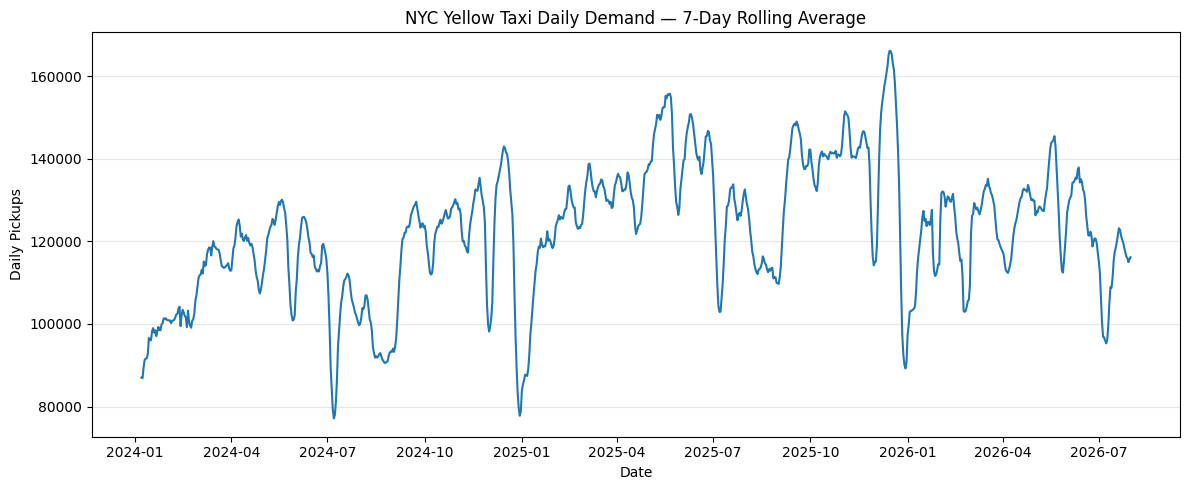

In [6]:
daily_demand = hourly.set_index("pickup_hour_ts")["trip_count"].resample("D").sum()

rolling_7d_daily = daily_demand.rolling(7).mean()

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_7d_daily.index,
    rolling_7d_daily.values,
)

plt.title("NYC Yellow Taxi Daily Demand — 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Daily Pickups")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    images_dir / "05_demand_history.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 3. Define the 24-Hour-Ahead Forecast

### Forecast target

For each target hour `t`, predict:

> **Yellow Taxi pickup count at hour `t`**

### Information available at prediction time

The forecast is made **24 hours before the target hour**.

Therefore, the newest demand value the model can use for target hour `t` is:

- `lag_24` = demand at `t - 24 hours`

Also create:

- `lag_48` = demand 48 hours earlier
- `lag_168` = same hour one week earlier
- lagged 24-hour rolling mean
- lagged 7-day rolling mean
- lagged 7-day rolling standard deviation

Calendar information about the target hour — such as hour of day and day of week — is known in advance and can safely be used.

### Leakage rule

Do **not** use `lag_1`, `lag_2`, or demand information from the 23 hours immediately preceding the target because those values would not yet be known 24 hours before the prediction target.


In [7]:
model_df = hourly.copy()

timestamp = model_df["pickup_hour_ts"]

model_df["year"] = timestamp.dt.year
model_df["month"] = timestamp.dt.month
model_df["hour"] = timestamp.dt.hour
model_df["day_of_week"] = timestamp.dt.dayofweek

model_df["is_weekend"] = (model_df["day_of_week"] >= 5).astype(int)

model_df["lag_24"] = model_df["trip_count"].shift(24)

model_df["lag_48"] = model_df["trip_count"].shift(48)

model_df["lag_168"] = model_df["trip_count"].shift(168)

known_24h_before = model_df["trip_count"].shift(24)

model_df["rolling_mean_24h"] = known_24h_before.rolling(24).mean()

model_df["rolling_mean_168h"] = known_24h_before.rolling(168).mean()

model_df["rolling_std_168h"] = known_24h_before.rolling(168).std()

feature_cols = [
    "year",
    "month",
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24h",
    "rolling_mean_168h",
    "rolling_std_168h",
]

model_df = model_df.dropna(subset=feature_cols + ["trip_count"]).reset_index(drop=True)

model_df[
    [
        "pickup_hour_ts",
        "trip_count",
        *feature_cols,
    ]
].head()


,pickup_hour_ts,trip_count,year,month,hour,day_of_week,is_weekend,lag_24,lag_48,lag_168,rolling_mean_24h,rolling_mean_168h,rolling_std_168h
0,2024-01-08 23:00:00,2527,2024,1,23,0,0,1564.0,5112.0,1475.0,2811.583333,3625.398810,2142.240743
1,2024-01-09 00:00:00,1014,2024,1,0,1,0,991.0,3870.0,966.0,2691.625000,3592.083333,2139.410934
2,2024-01-09 01:00:00,510,2024,1,1,1,0,425.0,2733.0,428.0,2595.458333,3550.886905,2133.319393
3,2024-01-09 02:00:00,237,2024,1,2,1,0,211.0,1925.0,244.0,2524.041667,3515.202381,2138.773661
4,2024-01-09 03:00:00,174,2024,1,3,1,0,204.0,1119.0,234.0,2485.916667,3487.101190,2151.118327


## 4. Temporal Train/Test Split

Time-series forecasting must preserve chronological order.

Use:

- **Training set:** all eligible observations before the final 8 weeks
- **Test set:** the final 8 weeks of the series

No random shuffle is used.

This setup simulates how a forecasting model would be evaluated on genuinely future data.


In [8]:
TEST_WEEKS = 8
test_hours = TEST_WEEKS * 7 * 24

if len(model_df) <= test_hours:
    raise ValueError("Not enough hourly observations for an 8-week test set.")

split_index = len(model_df) - test_hours

train = model_df.iloc[:split_index].copy()
test = model_df.iloc[split_index:].copy()

X_train = train[feature_cols]
y_train = train["trip_count"]

X_test = test[feature_cols]
y_test = test["trip_count"]

print(f"Training rows: {len(train):,}")
print(f"Test rows:     {len(test):,}")
print()
print(
    "Training target range:",
    train["pickup_hour_ts"].min(),
    "to",
    train["pickup_hour_ts"].max(),
)
print(
    "Test target range:",
    test["pickup_hour_ts"].min(),
    "to",
    test["pickup_hour_ts"].max(),
)


Training rows: 21,097
Test rows:     1,344

Training target range: 2024-01-08 23:00:00 to 2026-06-05 23:00:00
Test target range: 2026-06-06 00:00:00 to 2026-07-31 23:00:00


## 5. Seasonal Naive Baseline

Start with a simple benchmark before evaluating the machine-learning model.

### Baseline

For target hour `t`:

> **predict the demand observed at the same hour one week earlier**

This is exactly `lag_168`.

A machine-learning model is only useful if it improves meaningfully over a simple seasonal rule.


In [9]:
baseline_predictions = test["lag_168"].to_numpy()

baseline_preview = pd.DataFrame(
    {
        "timestamp": test["pickup_hour_ts"].head(10),
        "actual": y_test.head(10),
        "baseline_prediction": baseline_predictions[:10],
    }
)

baseline_preview


,timestamp,actual,baseline_prediction
21097,2026-06-06 00:00:00,9213,7329.0
21098,2026-06-06 01:00:00,7164,5722.0
21099,2026-06-06 02:00:00,5050,4264.0
21100,2026-06-06 03:00:00,3353,3086.0
21101,2026-06-06 04:00:00,2018,1815.0
21102,2026-06-06 05:00:00,1013,836.0
21103,2026-06-06 06:00:00,1368,1260.0
21104,2026-06-06 07:00:00,2142,1758.0
21105,2026-06-06 08:00:00,2920,2891.0
21106,2026-06-06 09:00:00,4335,4494.0


## 6. Gradient-Boosting Forecast Model

Use `HistGradientBoostingRegressor` because it:

- captures nonlinear relationships
- works well on structured tabular features
- does not require feature scaling
- is substantially more flexible than the seasonal baseline
- keeps the model relatively easy to interpret

Hyperparameters are fixed rather than extensively tuned. The purpose of this project is to demonstrate a sound forecasting workflow, not to maximize leaderboard performance.

Internal early stopping is disabled so the estimator does not create a random validation split inside the time-series training data.


In [10]:
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=250,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
)

model_predictions = model.predict(X_test)

model_predictions = np.clip(
    model_predictions,
    a_min=0,
    a_max=None,
)

model_predictions[:10]


array([7140.087951  , 5709.69460693, 4293.78758029, 3060.7914298 ,
       1789.49051521,  968.33012973, 1455.42516557, 1912.97143076,
       3077.08377609, 4540.08925138])

## 7. Forecast Evaluation

Evaluate both approaches using three metrics:

### MAE — Mean Absolute Error

Average absolute difference between actual and predicted hourly demand.

Lower is better.

### RMSE — Root Mean Squared Error

Similar to MAE, but places more weight on large misses.

Lower is better.

### WAPE — Weighted Absolute Percentage Error

Total absolute forecast error divided by total actual demand.

This gives an intuitive percentage measure of overall forecast error.

Lower is better.


In [21]:
def wape(y_true, y_pred):
    denominator = np.abs(y_true).sum()

    if denominator == 0:
        return np.nan

    return np.abs(y_true - y_pred).sum() / denominator * 100


def evaluate_forecast(
    name,
    y_true,
    y_pred,
):
    return {
        "model": name,
        "MAE": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "WAPE_pct": wape(
            np.asarray(y_true),
            np.asarray(y_pred),
        ),
    }


metrics = pd.DataFrame(
    [
        evaluate_forecast(
            "Seasonal Naive (lag 168)",
            y_test,
            baseline_predictions,
        ),
        evaluate_forecast(
            "HistGradientBoosting",
            y_test,
            model_predictions,
        ),
    ]
)

metrics


,model,MAE,RMSE,WAPE_pct
0,Seasonal Naive (lag 168),670.400298,1007.783310,13.621612
1,HistGradientBoosting,488.625153,710.626571,9.928191


In [12]:
baseline_mae = metrics.loc[
    metrics["model"] == "Seasonal Naive (lag 168)",
    "MAE",
].iloc[0]

model_mae = metrics.loc[
    metrics["model"] == "HistGradientBoosting",
    "MAE",
].iloc[0]

baseline_wape = metrics.loc[
    metrics["model"] == "Seasonal Naive (lag 168)",
    "WAPE_pct",
].iloc[0]

model_wape = metrics.loc[
    metrics["model"] == "HistGradientBoosting",
    "WAPE_pct",
].iloc[0]

mae_improvement_pct = (baseline_mae - model_mae) / baseline_mae * 100

wape_improvement_pct = (baseline_wape - model_wape) / baseline_wape * 100

print(f"MAE improvement vs baseline: {mae_improvement_pct:+.1f}%")

print(f"WAPE improvement vs baseline: {wape_improvement_pct:+.1f}%")


MAE improvement vs baseline: +27.1%
WAPE improvement vs baseline: +27.1%


## 8. Actual vs Predicted Demand

A forecast metric summarizes average performance, but a time-series plot helps reveal:

- whether daily patterns are captured
- whether peaks are systematically underpredicted
- whether forecast errors cluster during specific periods

Plot the **final two weeks** of the test period to keep the chart readable.


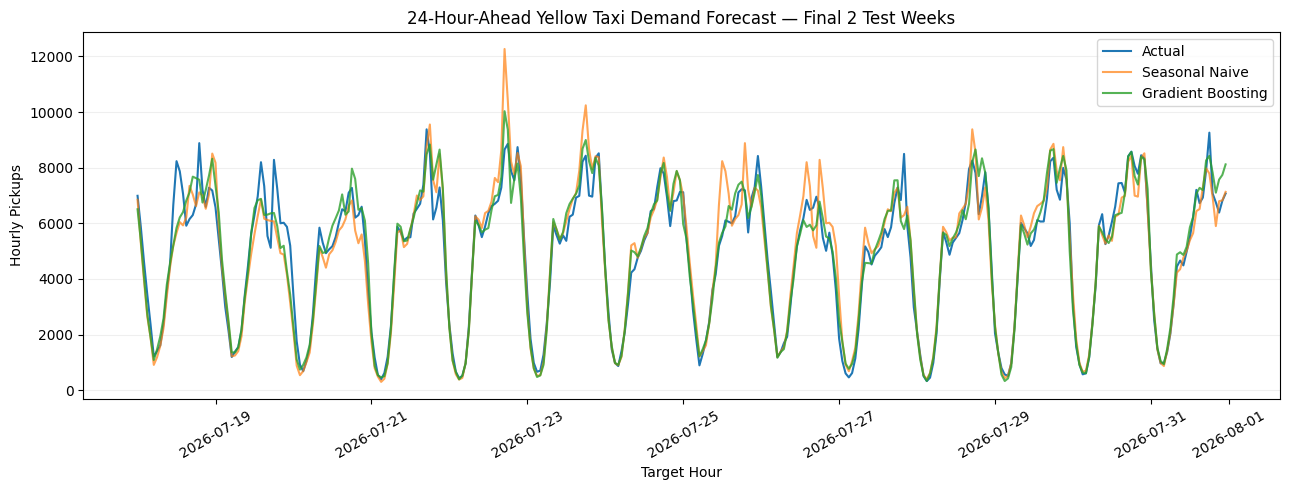

In [13]:
test_results = pd.DataFrame(
    {
        "timestamp": test["pickup_hour_ts"].to_numpy(),
        "actual": y_test.to_numpy(),
        "baseline": baseline_predictions,
        "model": model_predictions,
    }
)

plot_window = test_results.tail(14 * 24)

plt.figure(figsize=(13, 5))

plt.plot(
    plot_window["timestamp"],
    plot_window["actual"],
    label="Actual",
)

plt.plot(
    plot_window["timestamp"],
    plot_window["baseline"],
    label="Seasonal Naive",
    alpha=0.7,
)

plt.plot(
    plot_window["timestamp"],
    plot_window["model"],
    label="Gradient Boosting",
    alpha=0.8,
)

plt.title("24-Hour-Ahead Yellow Taxi Demand Forecast — Final 2 Test Weeks")
plt.xlabel("Target Hour")
plt.ylabel("Hourly Pickups")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    images_dir / "05_actual_vs_forecast.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 9. Error Analysis by Hour and Day of Week

Overall metrics can hide systematic weaknesses.

Inspect whether model error is larger:

- at particular hours of day
- on particular days of week

This helps identify where future forecasting improvements would be most valuable.


In [14]:
test_results["hour"] = test_results["timestamp"].dt.hour

test_results["day_of_week_num"] = test_results["timestamp"].dt.dayofweek

test_results["model_abs_error"] = np.abs(test_results["actual"] - test_results["model"])

error_by_hour = (
    test_results.groupby("hour")["model_abs_error"].mean().reset_index(name="MAE")
)

error_by_hour


,hour,MAE
0,0,707.778022
1,1,596.722689
2,2,397.903628
3,3,306.946333
4,4,232.443785
5,5,176.725920
6,6,212.269133
7,7,385.443707
8,8,466.614524
9,9,346.679470


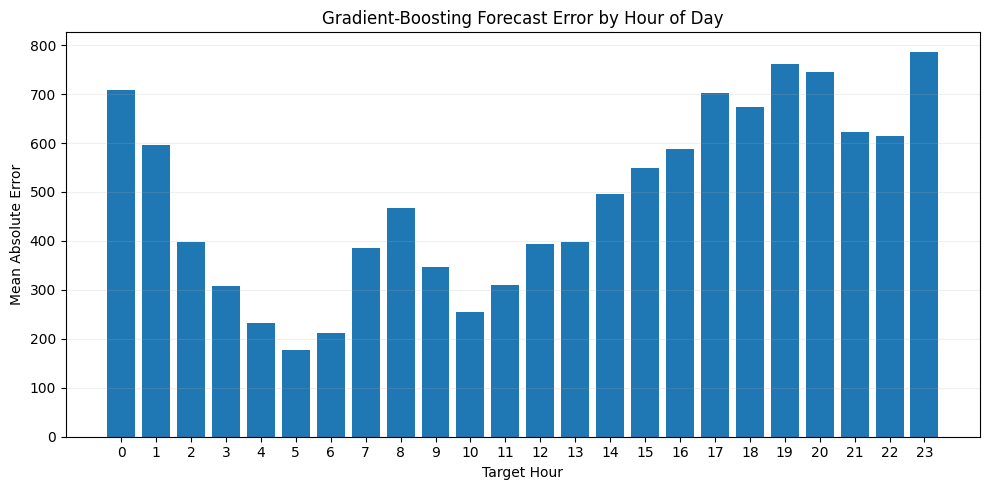

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    error_by_hour["hour"],
    error_by_hour["MAE"],
)

plt.title("Gradient-Boosting Forecast Error by Hour of Day")
plt.xlabel("Target Hour")
plt.ylabel("Mean Absolute Error")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    images_dir / "05_error_by_hour.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


In [16]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

error_by_day = (
    test_results.groupby("day_of_week_num")["model_abs_error"]
    .mean()
    .reindex(range(7))
    .rename(index=day_names)
    .reset_index()
    .rename(
        columns={
            "day_of_week_num": "day_of_week",
            "model_abs_error": "MAE",
        }
    )
)

error_by_day


,day_of_week,MAE
0,Monday,481.579504
1,Tuesday,435.998546
2,Wednesday,354.225246
3,Thursday,433.176555
4,Friday,610.206568
5,Saturday,638.683219
6,Sunday,466.506433


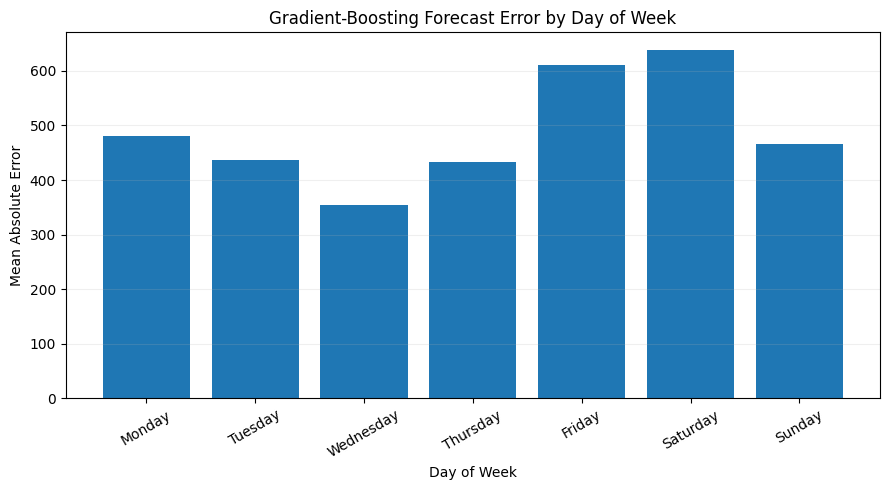

In [17]:
plt.figure(figsize=(9, 5))

plt.bar(
    error_by_day["day_of_week"],
    error_by_day["MAE"],
)

plt.title("Gradient-Boosting Forecast Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()

plt.savefig(
    images_dir / "05_error_by_day.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 10. Model Interpretation — Permutation Importance

`HistGradientBoostingRegressor` does not expose traditional tree feature importances.

Use **permutation importance** instead:

1. measure model performance normally
2. shuffle one feature at a time
3. measure how much forecast performance worsens

A larger importance means the model depends more heavily on that feature.

Because many time-series features are correlated, permutation importance should be treated as a **descriptive interpretability tool**, not a causal ranking.


In [18]:
importance_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance": importance_result.importances_mean,
            "importance_std": importance_result.importances_std,
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance


,feature,importance,importance_std
0,lag_168,827.000132,29.026588
1,lag_24,635.820699,16.620774
2,hour,411.709499,13.838494
3,day_of_week,194.516891,7.662726
4,rolling_mean_24h,72.516133,3.034222
5,rolling_mean_168h,68.469862,4.356444
6,rolling_std_168h,6.167277,1.359782
7,month,4.096727,1.147923
8,lag_48,3.504964,0.737280
9,year,0.000000,0.000000


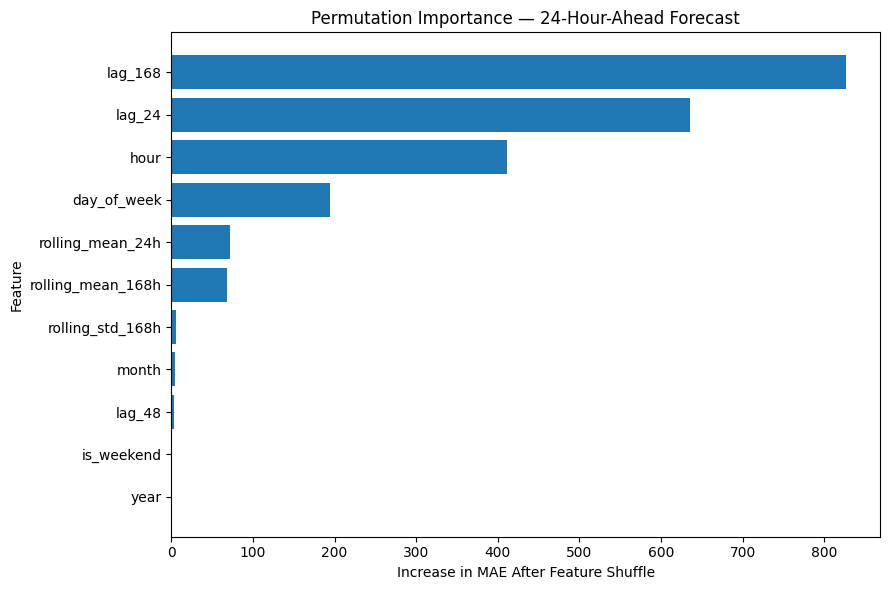

In [19]:
importance_chart = feature_importance.sort_values(
    "importance",
    ascending=True,
)

plt.figure(figsize=(9, 6))

plt.barh(
    importance_chart["feature"],
    importance_chart["importance"],
)

plt.title("Permutation Importance — 24-Hour-Ahead Forecast")
plt.xlabel("Increase in MAE After Feature Shuffle")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    images_dir / "05_permutation_importance.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## 11. Executive Summary

The cell below summarizes the actual forecast outputs.

It does not pre-write conclusions before the model has been evaluated.


In [20]:
worst_hour = error_by_hour.loc[error_by_hour["MAE"].idxmax()]

worst_day = error_by_day.loc[error_by_day["MAE"].idxmax()]

top_feature = feature_importance.iloc[0]

print("NYC Yellow Taxi 24-Hour Demand Forecast")
print("-" * 52)

print(
    f"1. Test period: "
    f"{test_results['timestamp'].min()} to "
    f"{test_results['timestamp'].max()}."
)

print(f"2. Seasonal-naive baseline WAPE: {baseline_wape:.2f}%.")

print(f"3. Gradient-boosting WAPE: {model_wape:.2f}%.")

print(
    f"4. Gradient boosting changes MAE by "
    f"{mae_improvement_pct:+.1f}% relative to the baseline."
)

print(f"5. Highest model MAE occurs around {int(worst_hour['hour']):02d}:00.")

print(f"6. Highest-error day of week: {worst_day['day_of_week']}.")

print(
    f"7. Most influential feature by permutation importance: {top_feature['feature']}."
)


NYC Yellow Taxi 24-Hour Demand Forecast
----------------------------------------------------
1. Test period: 2026-06-06 00:00:00 to 2026-07-31 23:00:00.
2. Seasonal-naive baseline WAPE: 13.62%.
3. Gradient-boosting WAPE: 9.93%.
4. Gradient boosting changes MAE by +27.1% relative to the baseline.
5. Highest model MAE occurs around 23:00.
6. Highest-error day of week: Saturday.
7. Most influential feature by permutation importance: lag_168.


## 12. Limitations and Next Steps

### Limitations

- The model forecasts **Yellow Taxi pickups only**, not total NYC ride-hailing demand.
- The target is citywide demand; spatial variation across taxi zones is not modeled.
- Weather, major events, transit disruptions, and taxi supply are not included.
- The forecast uses historical demand available at least 24 hours before each target hour.
- The model is evaluated on one final 8-week holdout period rather than repeated rolling-origin backtests.
- The gradient-boosting model uses fixed hyperparameters rather than extensive tuning.
- Permutation importance can be affected by correlation among lag and rolling features.

### Why these limitations are acceptable for Version 1

Version 1 focuses on:

- time-series feature engineering
- leakage prevention
- temporal validation
- baseline comparison
- interpretable model evaluation

The objective is a credible forecasting workflow, not maximum model complexity.

### Possible future extensions

- rolling-origin cross-validation
- weather and event features
- holiday indicators
- zone-level forecasting
- alternative gradient-boosting models
- probabilistic prediction intervals

Keep these extensions outside the core Version 1 scope.
